In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline

In [119]:
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV
from sklearn.preprocessing import RobustScaler,LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,r2_score,mean_absolute_error,mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import naive_bayes
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [22]:
df=pd.read_csv('../sources/diabetes.csv')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [24]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [25]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [26]:
df['Insulin'].unique()

array([  0,  94, 168,  88, 543, 846, 175, 230,  83,  96, 235, 146, 115,
       140, 110, 245,  54, 192, 207,  70, 240,  82,  36,  23, 300, 342,
       304, 142, 128,  38, 100,  90, 270,  71, 125, 176,  48,  64, 228,
        76, 220,  40, 152,  18, 135, 495,  37,  51,  99, 145, 225,  49,
        50,  92, 325,  63, 284, 119, 204, 155, 485,  53, 114, 105, 285,
       156,  78, 130,  55,  58, 160, 210, 318,  44, 190, 280,  87, 271,
       129, 120, 478,  56,  32, 744, 370,  45, 194, 680, 402, 258, 375,
       150,  67,  57, 116, 278, 122, 545,  75,  74, 182, 360, 215, 184,
        42, 132, 148, 180, 205,  85, 231,  29,  68,  52, 255, 171,  73,
       108,  43, 167, 249, 293,  66, 465,  89, 158,  84,  72,  59,  81,
       196, 415, 275, 165, 579, 310,  61, 474, 170, 277,  60,  14,  95,
       237, 191, 328, 250, 480, 265, 193,  79,  86, 326, 188, 106,  65,
       166, 274,  77, 126, 330, 600, 185,  25,  41, 272, 321, 144,  15,
       183,  91,  46, 440, 159, 540, 200, 335, 387,  22, 291, 39

In [27]:
df['Insulin'].value_counts()

Insulin
0      374
105     11
130      9
140      9
120      8
      ... 
178      1
127      1
510      1
16       1
112      1
Name: count, Length: 186, dtype: int64

In [28]:
#to_be_changed=(df[df['Insulin']==0].index).tolist()

In [29]:
#to_be_changed

In [30]:
#df['Insulin']=df['Insulin'].replace(0,np.nan)

In [31]:
#df['Insulin'].isnull().sum()

In [32]:
#df['Insulin']=df['Insulin'].fillna(df['Insulin'].median())

In [33]:
#df.info()

In [34]:
#df.describe()

In [35]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [40]:
columns_to_checked=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in columns_to_checked:
    zero_count=(df[col]==0).sum()
    zero_perecentage=100*zero_count/len(df)
    print(f"{col}:{zero_count},%{zero_perecentage:.2f}")

Glucose:5,%0.65
BloodPressure:35,%4.56
SkinThickness:227,%29.56
Insulin:374,%48.70
BMI:11,%1.43


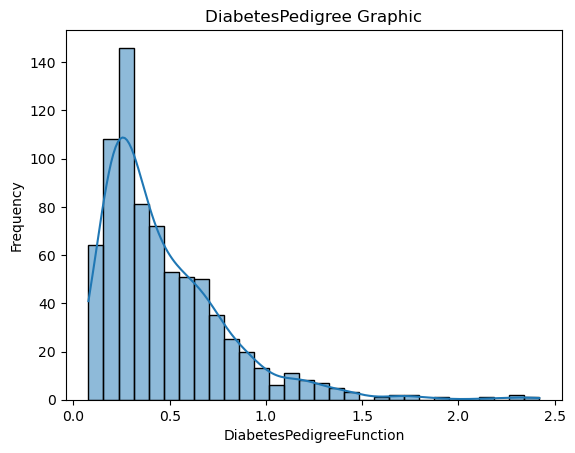

In [41]:
sns.histplot(df['DiabetesPedigreeFunction'],bins=30,kde=True)
plt.title('DiabetesPedigree Graphic')
plt.ylabel('Frequency')
plt.xlabel('DiabetesPedigreeFunction')
plt.show()

In [98]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']

In [110]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=15)

In [111]:
columns_to_checked

['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [112]:
medians={}
for col in columns_to_checked:
    median_value=X_train[X_train[col]!=0][col].median()
    medians[col]=median_value
    X_train[col]=X_train[col].replace(0,median_value)
    
for col in columns_to_checked:
    X_test[col]=X_test[col].replace(0,medians[col])

In [113]:
X_train.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

In [114]:
X_test.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,3.597403,122.038961,71.487013,29.376623,144.402597,32.483117,0.479565,33.064935
std,3.304818,32.320876,11.813495,10.513035,104.291511,6.946159,0.343303,12.118519
min,0.000000,61.000000,30.000000,7.000000,23.000000,18.400000,0.078000,21.000000
25%,1.000000,95.250000,64.000000,23.250000,108.250000,26.925000,0.254000,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.376500,28.000000
75%,5.750000,142.750000,80.000000,33.750000,129.500000,36.950000,0.603750,41.000000
max,13.000000,197.000000,106.000000,99.000000,846.000000,55.000000,2.329000,69.000000


In [115]:
robust=RobustScaler()
X_train_scaled=robust.fit_transform(X_train)
X_test_scaled=robust.transform(X_test)

In [116]:
ada=AdaBoostClassifier()

In [117]:
ada.fit(X_train_scaled,y_train)
y_pred=ada.predict(X_test_scaled)

In [118]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.81      0.84      0.82       104
           1       0.63      0.58      0.60        50

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.75      0.75      0.75       154

[[87 17]
 [21 29]]
0.7532467532467533


In [120]:
ada_boost_param={'n_estimators':[50,100,200,500],'learning_rate':[0.1,0.01,1,10]}

In [127]:
grid=GridSearchCV(estimator=AdaBoostClassifier(),param_grid=ada_boost_param,cv=3,verbose=2,n_jobs=-1)

In [128]:
grid.fit(X_train_scaled,y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.01, 1, 10],
                         'n_estimators': [50, 100, 200, 500]},
             verbose=2)

In [134]:
grid.best_params_

{'learning_rate': 1, 'n_estimators': 500}

In [135]:
ada=AdaBoostClassifier(learning_rate=1,n_estimators=500)

In [136]:
ada.fit(X_train_scaled,y_train)
y_pred=ada.predict(X_test_scaled)

In [137]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.81      0.84      0.82       104
           1       0.63      0.58      0.60        50

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.75      0.75      0.75       154

[[87 17]
 [21 29]]
0.7532467532467533


In [139]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [141]:
models={'Logistic Regression':LogisticRegression(),
       'SVC':SVC(),
        'Gaussian':GaussianNB(),
        'Decision Tree':DecisionTreeClassifier(),
        'RandomForest':RandomForestClassifier(),
        'KNN':KNeighborsClassifier()
       }

In [151]:
def calculate_model_metrics(true,predicted):
    classic=classification_report(true,predicted)
    confusion=confusion_matrix(true,predicted)
    score=accuracy_score(true,predicted)
    return classic,confusion,score

In [152]:
for i in range (len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train_scaled,y_train)
    y_pred_train=model.predict(X_train_scaled)
    y_pred_test=model.predict(X_test_scaled)
    class_check_train,confusion_check_train,score_check_train=calculate_model_metrics(y_pred_train,y_train)
    class_check_test,confusion_check_test,score_check_test=calculate_model_metrics(y_pred_test,y_test)
    print(list(models.values())[i])
    print('Evulation for Train Set:')
    print('class:',class_check_train)
    print('confusion:',confusion_check_train)
    print('score:',score_check_train)
    print('---------------------------------')
    print('Evulation for Test Set:')
    print('class',class_check_test)
    print('confusion',confusion_check_test)
    print('score',score_check_test)
    print('---------------------------------')
    print('---------------------------------')
    print('\n')

LogisticRegression()
Evulation for Train Set:
class:               precision    recall  f1-score   support

           0       0.89      0.80      0.84       435
           1       0.60      0.75      0.67       179

    accuracy                           0.78       614
   macro avg       0.74      0.77      0.75       614
weighted avg       0.80      0.78      0.79       614

confusion: [[347  88]
 [ 45 134]]
score: 0.7833876221498371
---------------------------------
Evulation for Test Set:
class               precision    recall  f1-score   support

           0       0.82      0.82      0.82       109
           1       0.57      0.58      0.57        45

    accuracy                           0.75       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.75      0.75      0.75       154

confusion [[89 20]
 [19 26]]
score 0.7467532467532467
---------------------------------
---------------------------------


SVC()
Evulation for Train Set:
class:        